In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import gdown

file_id = '1DL3V5U2vHw3xPL42vuBxKz0QRMrytLLh' # Extracted from the provided URL
output_filename = 'dataset.csv'

gdown.download(id=file_id, output=output_filename, quiet=False)
print(f"File downloaded as '{output_filename}'")

Downloading...
From (original): https://drive.google.com/uc?id=1DL3V5U2vHw3xPL42vuBxKz0QRMrytLLh
From (redirected): https://drive.google.com/uc?id=1DL3V5U2vHw3xPL42vuBxKz0QRMrytLLh&confirm=t&uuid=ee82c2f2-c505-4b5f-a827-6a0b1247a5ec
To: /content/dataset.csv
100%|██████████| 556M/556M [00:07<00:00, 71.7MB/s]

File downloaded as 'dataset.csv'


In [ ]:
import pandas as pd
df=pd.read_csv('dataset.csv')
df.head()

/tmp/ipykernel_1135/2353016527.py:2: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('dataset.csv')


,Title,Text,Subreddit,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78
0,exposure does not work!,I have struggled with social anxiety from chil...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Panic attack? derealization? can't go to docto...,"Back in March (I know, a while ago D:), I woke...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,How long can a panic attack last?!,I've been withdrawing from medicines lately (e...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Stepping stones,"First time poster, long time lurker. \n\nI've ...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Coping with anxiety over climate change, on th...","Hi all,\n\nI made a throwaway account as my ma...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

In [ ]:
print(df.shape)
print(df.columns)
df.info()

(488738, 3)
Index(['Title', 'Text', 'Subreddit'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488738 entries, 0 to 488737
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Title      488608 non-null  object
 1   Text       488573 non-null  object
 2   Subreddit  488535 non-null  object
dtypes: object(3)
memory usage: 11.2+ MB


In [ ]:
df = df.dropna()

print(df.isnull().sum())

Title        0
Text         0
Subreddit    0
dtype: int64


In [ ]:
valid_labels = [
    "depression",
    "mentalhealth",
    "Anxiety",
    "bipolar",
    "BPD",
    "schizophrenia",
    "autism"
]

# normalize text (very important)
df["Subreddit"] = df["Subreddit"].astype(str).str.strip()

# keep only valid labels
df = df[df["Subreddit"].isin(valid_labels)]

df = df[df["Subreddit"] != "mentalhealth"]

df["Subreddit"].value_counts()

,count
Subreddit,
depression,258490
Anxiety,86242
bipolar,41490
BPD,38210
schizophrenia,17505
autism,7142


In [ ]:
df["text_length"] = df["Text"].apply(lambda x: len(str(x).split()))

df["text_length"].describe()

,text_length
count,449079.000000
mean,184.987488
std,224.415564
min,0.000000
25%,60.000000
50%,121.000000
75%,229.000000
max,6597.000000


In [ ]:
df = df[df["text_length"] > 0]
print(df.shape)

(449000, 4)


In [ ]:
def trim_text(text, max_words=500):
    words = text.split()
    return " ".join(words[:max_words])

df["Text"] = df["Text"].apply(trim_text)
df.shape

(449000, 4)

In [ ]:
df["content"] = df["Title"] + " " + df["Text"]

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()  # Convert to string before applying lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["content"].apply(clean_text)

In [ ]:
df["clean_text"]

,clean_text
0,exposure does not work i have struggled with s...
1,panic attack derealization cant go to doctors ...
2,how long can a panic attack last ive been with...
3,stepping stones first time poster long time lu...
4,coping with anxiety over climate change on the...
...,...
488733,religion and paranoid conversation ok ive got ...
488734,isnt this a little weird for being tardive dys...
488735,is this a symptom of schizophrenia or somethin...
488736,anyone seen the new black mirror episode bande...


In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

In [ ]:
df["clean_text"].head()

,clean_text
0,exposure does work struggled social anxiety ch...
1,panic attack derealization doctors advice appr...
2,long panic attack ive withdrawing medicines la...
3,stepping stones time poster long time lurker i...
4,coping anxiety climate change verge considerin...


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Subreddit"],
    random_state=42
)

print(train_df.shape, test_df.shape)

(359200, 6) (89800, 6)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df["clean_text"])
X_test = vectorizer.transform(test_df["clean_text"])

print(X_train.shape, X_test.shape)

(359200, 5000) (89800, 5000)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(train_df["Subreddit"])
y_test = le.transform(test_df["Subreddit"])

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_res.shape)

Before SMOTE: (359200, 5000)
After SMOTE: (1240572, 5000)


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)

model.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:43:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=6, ...)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Overall Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Overall Accuracy: 0.7784966592427617

Classification Report:

               precision    recall  f1-score   support

      Anxiety       0.80      0.75      0.77     17246
          BPD       0.68      0.59      0.63      7639
       autism       0.73      0.79      0.76      1428
      bipolar       0.79      0.64      0.70      8296
   depression       0.85      0.84      0.85     51691
schizophrenia       0.32      0.70      0.44      3500

     accuracy                           0.78     89800
    macro avg       0.70      0.72      0.69     89800
 weighted avg       0.80      0.78      0.79     89800



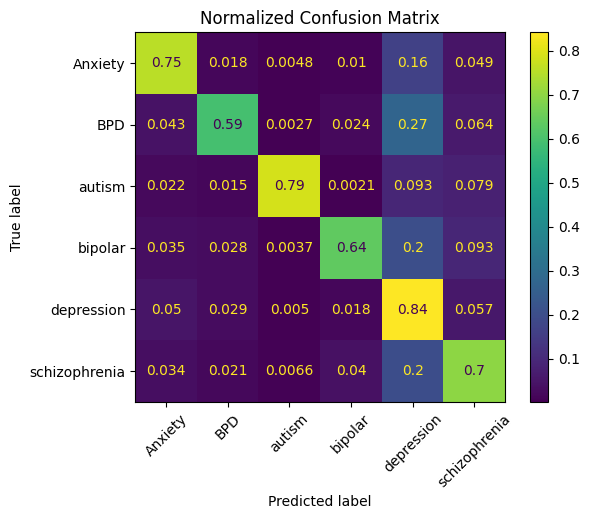

In [ ]:
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(xticks_rotation=45)
plt.title("Normalized Confusion Matrix")
plt.show()